In [89]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [90]:
image = cv2.imread('Lenna.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image = image.astype(np.float32) / 255.0
print(image.dtype)

float32


## 定義一些基本工具

In [91]:
#1.padding方法 (重複邊界方法，不含交疊點)
def pad_reflect(x, pad):
    h, w = x.shape
    y = np.empty((h + 2*pad, w + 2*pad), dtype=x.dtype)
    y[pad:pad+h, pad:pad+w] = x
    # 上下
    y[:pad, pad:pad+w] = x[1:pad+1][::-1, :]
    y[pad+h:, pad:pad+w] = x[h-pad-1:h-1][::-1, :]
    # 左右
    y[:, :pad] = y[:, pad:2*pad][:, ::-1]
    y[:, pad+w:] = y[:, w:w+pad][:, ::-1]
    return y

#2.捲積方法
def conv2d(image, kernel):
    img = image.astype(np.float32)
    k = kernel.astype(np.float32)
    kh, kw = k.shape
    pad = kh // 2
    padded = pad_reflect(img, pad)
    out = np.zeros_like(img, dtype=np.float32)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            roi = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(roi * k)
    return out

#3.高斯kernel
def gaussian_kernel(sigma=1.0, ksize=None):
    if ksize is None:
        ksize = int(np.ceil(6*sigma)) | 1  # 轉奇數
    assert ksize % 2 == 1 and ksize > 0
    ax = np.arange(-(ksize//2), ksize//2 + 1, dtype=np.float32)
    xx, yy = np.meshgrid(ax, ax)
    ker = np.exp(-(xx**2 + yy**2) / (2*sigma*sigma))
    ker /= ker.sum()
    return ker

## Unsharp Masking

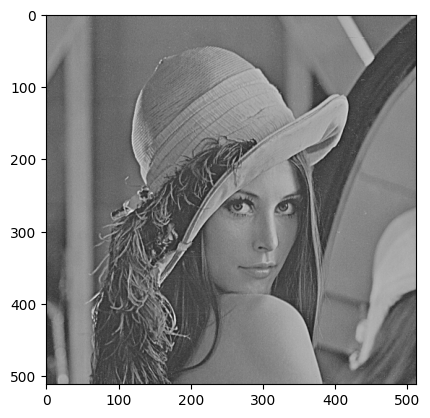

In [92]:
sigma = 1.5
amount = 1.5
blur = conv2d(image, gaussian_kernel(sigma))
mask = image - blur
out = image + amount * mask

plt.imshow(out, cmap='gray')

## Laplacian Kernel

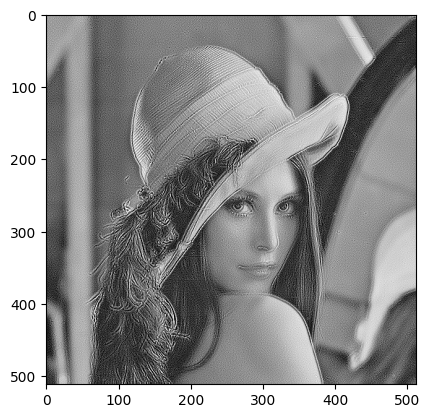

In [93]:
k=1.0
connectivity = 4
# --- 2. 定義 Laplacian kernel (4鄰) ---
lap_kernel = np.array([[0, -1, 0],
            [-1, 4, -1],
            [0, -1, 0]], dtype=np.float32)

# Step 2: Laplacian 運算（二階導數）
lap = conv2d(image, lap_kernel)

k = 2
sharp = image - k * lap   # lap 可正可負
sharp = np.clip(sharp, 0, 1)
plt.imshow(sharp, cmap='gray')